<a href="https://colab.research.google.com/github/nayra0/topicosBiotecnologia/blob/main/Classifica%C3%A7%C3%A3o_de_Texto_Machine_Learning_NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Classificação de texto usando algoritmos de Machine Learning**

**Programa de Pós-Graduação em Biotecnologia (PPGBiotec)**

**Disciplina:** Tópicos em Biotecnologia 2

**Professor:** Adonias Caetano de Oliveira

**Cursos:** Mestrado e Doutorado em Biotecnologia

🎯 **Objetivo:** Exemplo de classificação de texto com dataset em Português


### **Instalação de pacotes** 📦

In [ ]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 35.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### **Importando bibliotecas** 📚

In [ ]:
# ============================================================
# 1. MANIPULAÇÃO E PREPARAÇÃO DOS DADOS
# ============================================================

import pandas as pd
import numpy as np

from collections import defaultdict
from sklearn.utils import shuffle


# ============================================================
# 2. LIMPEZA E PRÉ-PROCESSAMENTO DE TEXTO
# ============================================================

import re
import nltk
import spacy

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet as wn
from string import punctuation


# ============================================================
# 3. REPRESENTAÇÃO / VETORIZAÇÃO DOS TEXTOS
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer


# ============================================================
# 4. PREPARAÇÃO PARA MACHINE LEARNING
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score


# ============================================================
# 5. ALGORITMOS DE MACHINE LEARNING
# ============================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
import xgboost as xgb


# ============================================================
# 6. AVALIAÇÃO DOS MODELOS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 8. VISUALIZAÇÃO DE TEXTOS / WORD CLOUD
# ============================================================

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image
from os import path

### **Carregando dataset** 🔃

In [ ]:
url = 'https://drive.google.com/file/d/1o89ljfGKPjO8IH6m0an7wXurteCqeo9Q/view?usp=sharing'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

# read the data
dataset = pd.read_csv(read_url)

TEXT = "comment"
TARGET = "odio"

# display the first 5 rows
dataset.head()

,certeza_disc_clas_1,certeza_disc_clas_2,certeza_disc_clas_3,certeza_ofens_clas_1,certeza_ofens_clas_2,certeza_ofens_clas_3,comment,date,disc_clas_1,disc_clas_2,disc_clas_3,id_autor_1,id_autor_2,id_autor_3,keyword,ofens_clas_1,ofens_clas_2,ofens_clas_3,source,odio
0,-1.0,-1.0,4.0,4.0,5.0,4.0,Eu fui ver o Twitter da garota e já dou de car...,2020-12-23 21:17:31,0.0,0.0,1.0,-MbqEhLQ5DHE4JKVnSYz,-MbrOtpTLDyCIXXqMS8s,-MbxUAktPHOvanZLgccl,antifeminista,0.0,0.0,1.0,Twitter,0
1,5.0,1.0,5.0,5.0,5.0,5.0,@NOME @NOME Jaja te bloqueio denovo seu resto ...,2020-12-27 20:51:47,0.0,0.0,1.0,-MbrXeGPm84uPDqKwzsp,-MbxCpLCV0T1V7o0TS8U,-Mc-A6HAii__JnTbfS87,mal_comida,1.0,1.0,1.0,Twitter,0
2,-1.0,-1.0,-1.0,5.0,5.0,5.0,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,2020-12-24 14:16:29,0.0,0.0,0.0,-MbpxGPiip0WCKKay75Y,-MbxAkmihTQeEppUb3js,-MbxCzO_1ftJ-VJJcgJv,antifeminista,0.0,0.0,0.0,Twitter,0
3,-1.0,-1.0,-1.0,4.0,5.0,5.0,Quando vejo uma mulher antifeminista eu só con...,2020-12-23 19:31:28,0.0,0.0,0.0,-MbneJBhF1GNC7xPlc-V,-MbqFQINR5epWplcJrfU,-Mbwgys1T2GNBckrws-l,antifeminista,0.0,0.0,0.0,Twitter,0
4,5.0,5.0,4.0,5.0,5.0,3.0,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,2020-12-20 18:04:36,1.0,1.0,1.0,-MbqHpEUMADtFHR3ci3y,-MbvHmh93AGhmpw2J54j,-MbxDaKZSOQDgemnY-H6,feminazi,1.0,1.0,1.0,Twitter,1


### **Preparando dados (Pré-processamento)** ⚙

In [ ]:
# Downloads necessários no Colab
nltk.download('stopwords') # Listas de palavras frequentesRemoção de stopwordsde, a, o, que, e
nltk.download('punkt') # Modelos/dados de tokenização. Separação de textos em sentenças/tokens
nltk.download('punkt_tab') # Tabelas usadas pelo tokenizador. Necessário para word_tokenize()
nltk.download('rslp') # Regras do stemmer RSLP. Stemming para português

nlp = spacy.load("pt_core_news_sm") # Modelo spaCy para português
stopwords_pt = set(stopwords.words("portuguese"))
stemmer = RSLPStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [ ]:
def processar_texto(texto, is_stemming = True):
    # 1. Normalização
    texto = texto.lower() # Normaliza para minúsculo
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)  # Remove URLs
    texto = re.sub(r'[^\w\s]', '', texto)                # Remove pontuação
    texto = re.sub(r'\s+', ' ', texto).strip()           # Remove espaços extras
    texto = ''.join(c for c in texto if c not in punctuation) # Remove pontuações

    # 2. Tokenização
    texto_tokenizado = nltk.word_tokenize(texto, language="portuguese")

    # 3. Remoção de stopwords e tokens muito curtos
    texto_sem_stopwords= [
        token for token in texto_tokenizado
        if token not in stopwords_pt and len(token) > 2
    ]

    # Atenção: Usar Stemming ou Lematização (não ambos)

    if is_stemming : # aplica stemming
      texto_processado = [stemmer.stem(token) for token in texto_sem_stopwords]
    else: # aplica lematização
      doc = nlp(" ".join(texto_sem_stopwords))
      texto_processado = [token.lemma_ for token in doc]

    # Converte a lista de tokens em uma string
    texto_processado = " ".join(texto_processado)

    return texto_processado



In [ ]:
data_process = dataset.copy()
# Preenche quaisquer valores NaN na coluna de texto com uma string vazia
old_texts = data_process[TEXT].fillna('')
new_texts = []
for text in old_texts:
    text = processar_texto(text)
    new_texts.append(text)

data_process[TEXT] = new_texts

### **Balanceamento do conjunto de dados** 📊

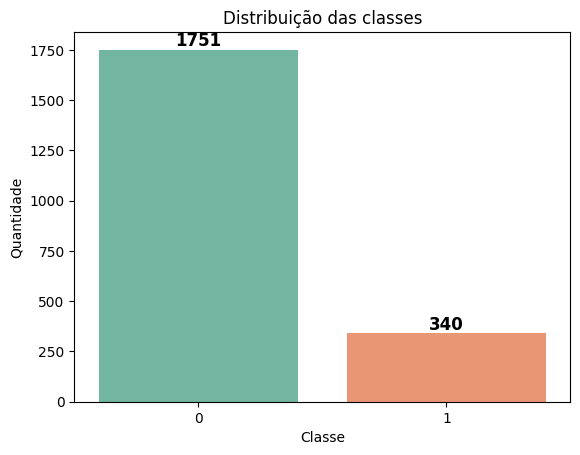

In [ ]:
ax = sns.countplot(
    x=TARGET,
    data=data_process,
    hue=TARGET,
    palette="Set2",
    legend=False
)

# Quantidade sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight="bold")

plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes")
plt.show()

### **Nuvem de palavras** ☁

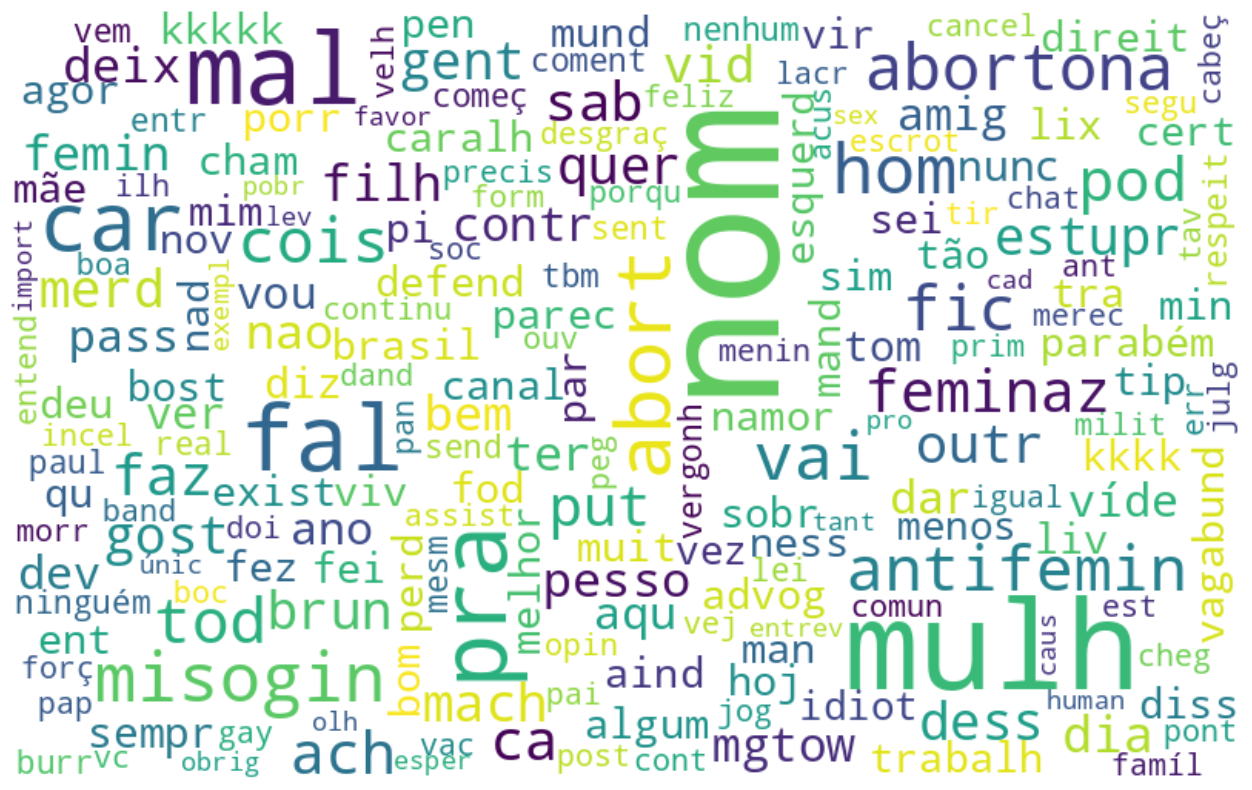

In [ ]:
new_texts = data_process[TEXT]
all_words = ' '.join([text for text in new_texts])
word_cloud = WordCloud(width= 800, height= 500, max_font_size = 110, background_color="white", collocations = False).generate(all_words)
plt.figure(figsize=(20,10))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### **Classificação de texto** 🤖



#### **Validação cruzada K-fold**

In [ ]:
# Cria o vetorizador
tfidf = TfidfVectorizer()

# Aprende o vocabulário e transforma os textos em vetores
X = tfidf.fit_transform(data_process[TEXT])
Y = data_process[TARGET]

In [ ]:
train_df, test_df, train_label, test_label = train_test_split(X, Y, test_size=0.20, random_state=42)

#### **Treinando algoritmos de Machine Learning**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

NaiveBayes = MultinomialNB()
NaiveBayes.fit(train_df, train_label)

MultinomialNB()

#### **Testando os modelos de Machine Learning**

In [ ]:
pred_naive_test = NaiveBayes.predict(test_df)

In [ ]:
def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Greens")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    plt.ylabel('Saída real')
    plt.xlabel('Saída predita');

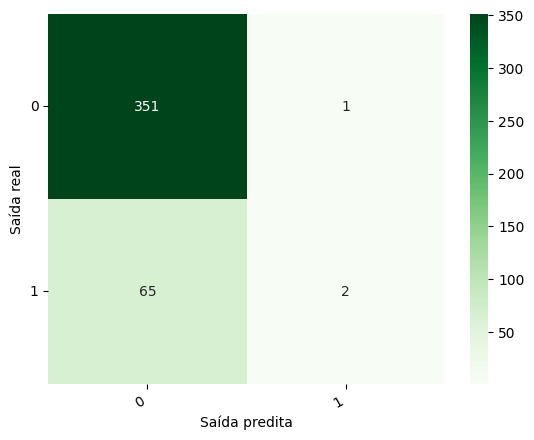

In [ ]:
cm_NB = confusion_matrix(test_label, pred_naive_test)
show_confusion_matrix(cm_NB)

In [ ]:
print(classification_report(test_label, pred_naive_test))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       352
           1       0.67      0.03      0.06        67

    accuracy                           0.84       419
   macro avg       0.76      0.51      0.49       419
weighted avg       0.82      0.84      0.78       419

